<a href="https://colab.research.google.com/github/rekhadhorigol/mcse-datathon/blob/main/MCSE_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCSE Datathon

Rekha Dhorigol, PES1UG24CS370

Manasa K, PES1UG25CS824

Sanchita Sunil, PES1UG24CS419

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Set - 21 Dataset_Anime.csv to Set - 21 Dataset_Anime.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("Set - 21 Dataset_Anime.csv")

df.head()

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, someth...","['Action', 'Military', 'Adventure', 'Comedy', ...",NaN,64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/...,https://myanimelist.net/anime/5114/Fullmetal_A...
4,31758,Kizumonogatari III: Reiketsu-hen,After helping revive the legendary vampire Kis...,NaN,6-Jan-17,1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/815...,https://myanimelist.net/anime/31758/Kizumonoga...


In [ ]:
# Column Names & Data Types
df.info()

# Shape of Dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Drop unnecessary columns
df_clean = df.drop(["img_url", "link", "synopsis"], axis=1)
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19311 entries, 0 to 19310
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   uid         19311 non-null  int64  
 1   title       19311 non-null  object 
 2   synopsis    18336 non-null  object 
 3   genre       18346 non-null  object 
 4   aired       18346 non-null  object 
 5   episodes    18605 non-null  float64
 6   members     19311 non-null  int64  
 7   popularity  19311 non-null  int64  
 8   ranked      16099 non-null  float64
 9   score       18732 non-null  float64
 10  img_url     19131 non-null  object 
 11  link        19311 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 1.8+ MB
Rows: 19311
Columns: 12


,uid,title,genre,aired,episodes,members,popularity,ranked,score
0,28891,Haikyuu!! Second Season,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82
1,23273,Shigatsu wa Kimi no Uso,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83
2,34599,Made in Abyss,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83
3,5114,Fullmetal Alchemist: Brotherhood,"['Action', 'Military', 'Adventure', 'Comedy', ...",NaN,64.0,1615084,4,1.0,9.23
4,31758,Kizumonogatari III: Reiketsu-hen,NaN,6-Jan-17,1.0,214621,502,22.0,8.83


In [ ]:
# Null Values
df_clean.isnull().sum()

# Duplicate Records
df_clean.duplicated().sum()

# Example cleaning: Remove records with missing score
df_clean = df_clean.dropna(subset=['score'])

# Replace missing episodes with median
df_clean['episodes'].replace(0, np.nan, inplace=True)
df_clean['episodes'].fillna(df_clean['episodes'].median(), inplace=True)

print("Cleaned Shape:", df_clean.shape)

Cleaned Shape: (18732, 9)


/tmp/ipython-input-3664786122.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['episodes'].replace(0, np.nan, inplace=True)
/tmp/ipython-input-3664786122.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
columns = ['episodes','members','popularity','ranked','score']
df_clean[columns].describe()

,episodes,members,popularity,ranked,score
count,18732.000000,1.873200e+04,18732.000000,16099.000000,18732.000000
mean,11.386504,3.548154e+04,7710.138480,6866.524194,6.436107
std,47.793617,1.137553e+05,4693.328032,4390.018768,1.007941
min,1.000000,2.500000e+01,1.000000,1.000000,1.250000
25%,1.000000,3.760000e+02,3682.500000,2895.500000,5.770000
50%,2.000000,2.389000e+03,7521.000000,6963.000000,6.410000
75%,12.000000,1.483900e+04,11647.250000,10601.500000,7.150000
max,3057.000000,1.871043e+06,16320.000000,14675.000000,9.230000


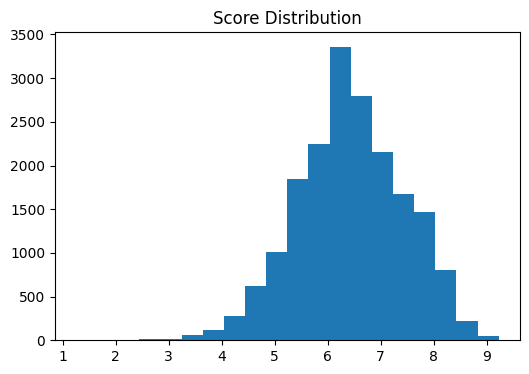

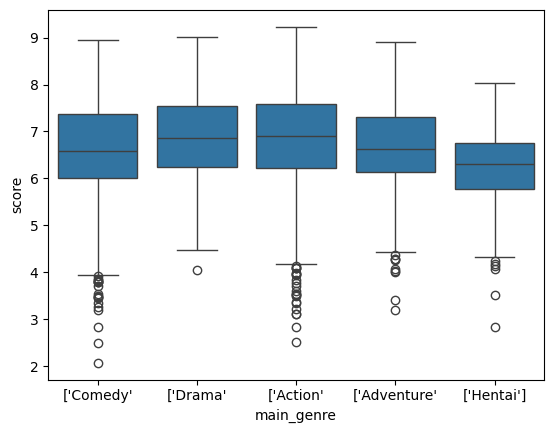

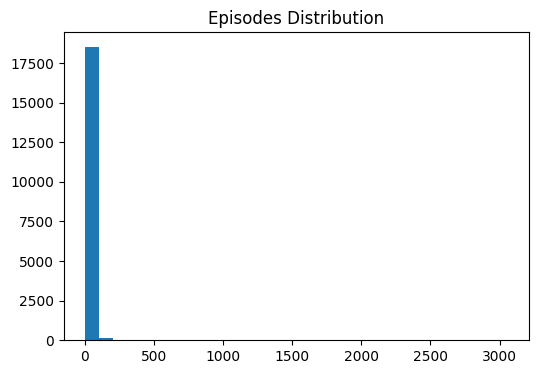

In [ ]:
# Score Distribution
plt.figure(figsize=(6,4))
plt.hist(df_clean['score'], bins=20)
plt.title("Score Distribution")
plt.show()

# Extract primary genre
df_clean['main_genre'] = df_clean['genre'].str.split(',').str[0]

# Top 5 Genres Boxplot
top_genres = df_clean['main_genre'].value_counts().head(5).index
sns.boxplot(x='main_genre', y='score', data=df_clean[df_clean['main_genre'].isin(top_genres)])
plt.show()

# Episodes Distribution
plt.figure(figsize=(6,4))
plt.hist(df_clean['episodes'], bins=30)
plt.title("Episodes Distribution")
plt.show()


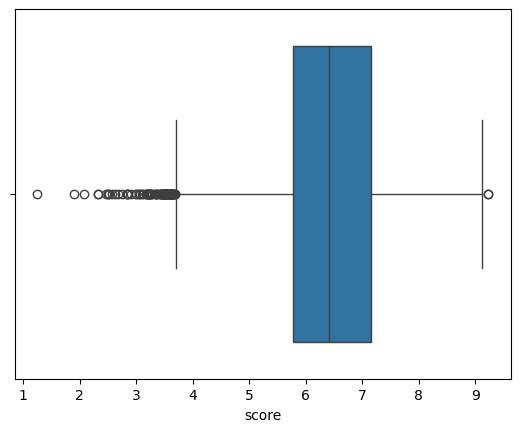

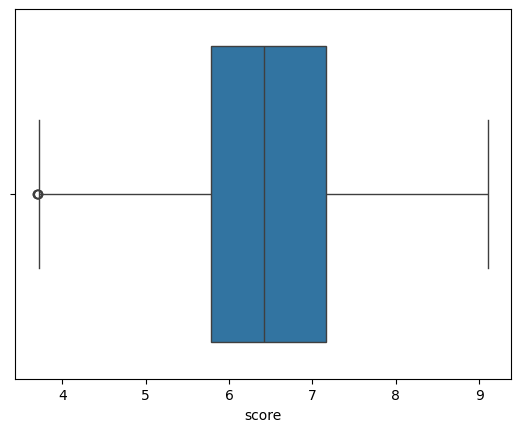

In [ ]:
def remove_outliers(col):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_no_out = remove_outliers('score')
sns.boxplot(x=df_clean['score'])
plt.show()

sns.boxplot(x=df_no_out['score'])
plt.show()

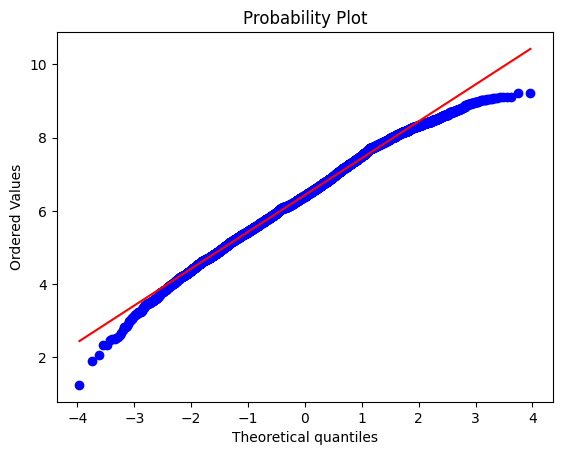

In [ ]:
stats.probplot(df_clean['score'], dist="norm", plot=plt)
plt.show()

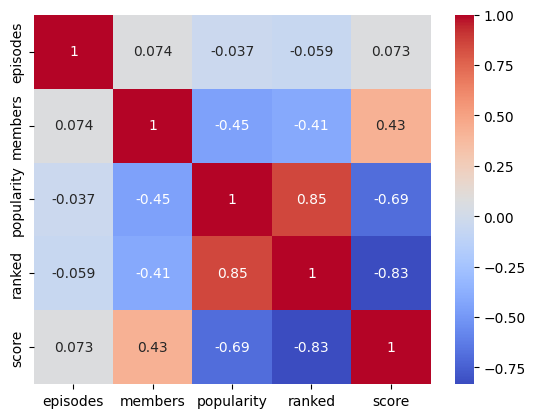

score         1.000000
members       0.426010
episodes      0.073185
popularity   -0.694138
ranked       -0.834105
Name: score, dtype: float64


In [ ]:
numeric = df_clean[['episodes','members','popularity','ranked','score']]
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

print(numeric.corr()['score'].sort_values(ascending=False))


In [ ]:
score_mean = df_clean['score'].mean()
score_std = df_clean['score'].std()
n = len(df_clean)

# 95% CI
ci_lower = score_mean - 1.96*(score_std/np.sqrt(n))
ci_upper = score_mean + 1.96*(score_std/np.sqrt(n))
print("95% Confidence Interval:", (ci_lower, ci_upper))


95% Confidence Interval: (np.float64(6.4216722550938785), np.float64(6.450541069697921))


In [ ]:
members_mean = df_clean['members'].mean()
members_std = df_clean['members'].std()
n = len(df_clean)

for z in [1.64, 1.96, 2.58]:  # 90%, 95%, 99%
    ME = z * members_std/np.sqrt(n)
    print(f"Margin of Error (z={z}):", ME)

Margin of Error (z=1.64): 1363.0869420844667
Margin of Error (z=1.96): 1629.0551259058261
Margin of Error (z=2.58): 2144.36848205971


In [ ]:
genre1 = df_clean[df_clean['main_genre']=="Action"]['score']
genre2 = df_clean[df_clean['main_genre']=="Romance"]['score']

t, p = ttest_ind(genre1, genre2)
print("p-value =", p)

p-value = nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Correlation: 0.4260095651786223


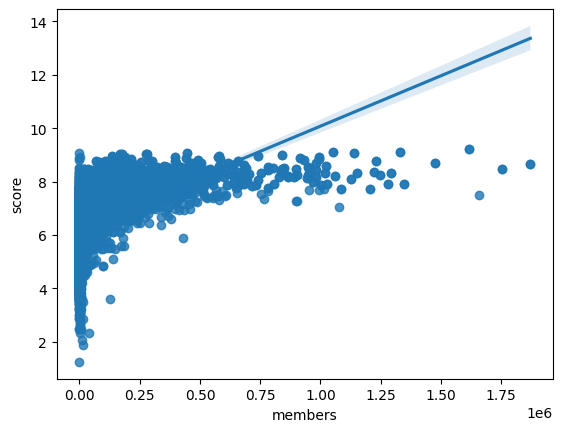

In [ ]:
corr, _ = pearsonr(df_clean['members'], df_clean['score'])
print("Correlation:", corr)

sns.regplot(x='members', y='score', data=df_clean)
plt.show()

In [ ]:
X = df_clean[['members']]
y = df_clean['score']

model = LinearRegression()
model.fit(X,y)

print("beta0:", model.intercept_)
print("beta1:", model.coef_[0])

y_pred = model.predict(X)
print("R² Score:", r2_score(y, y_pred))


beta0: 6.302174467194147
beta1: 3.7747007333014404e-06
R² Score: 0.18148414962367887
